In [2]:
from AG_lib import geodata
from AG_lib.geodata import SeismicGather

import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

# Download and read in the synthetic data

In [3]:
# download the synthetic data
# In this case I generated a share link in the google drive, and use the file id
# in the share link.


file_id = 'long_offset_three_layer.npz'     # this is the id in your google drive share link

In [4]:
reload(geodata)

shot_gather = geodata.SeismicGather()  # create a SeismicGather instance
shot_gather.read_synthetic_data(file_id)   # read in the synthetic model output

shot_gather.wiggle_plot(scale=1000)
plt.xlim(0,10000)

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

The head wave is weak, but visible in the data

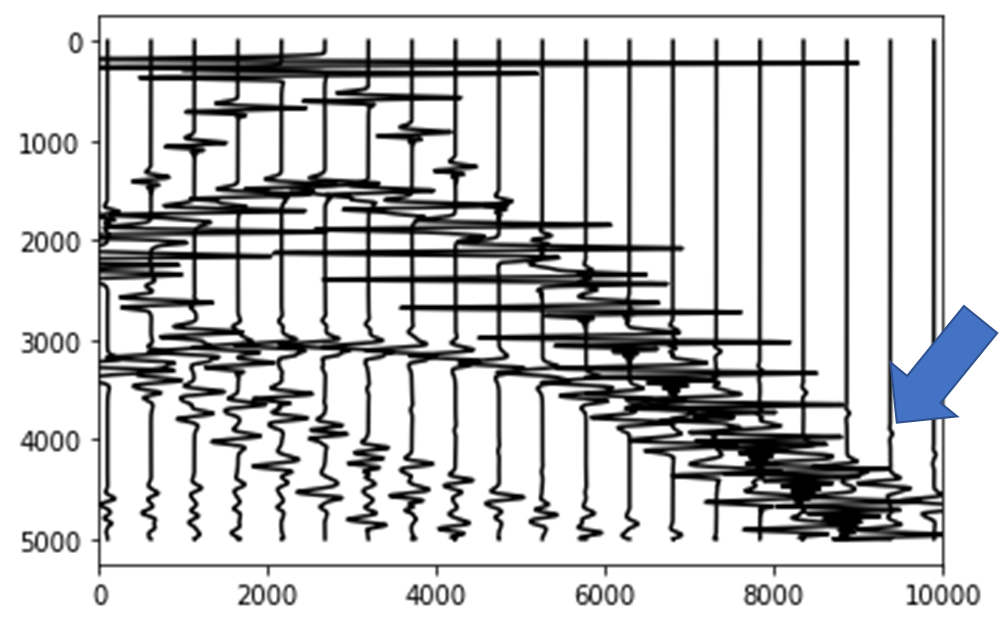



Let's add some methods to your geodata class, so we can make interactive data plots to help you pick the first break travel time.

adding the following library imports:
````
import plotly.express as px
import pandas as pd
````

adding the following methods to your geodata class:
````
    def get_taxis(self):
        taxis = np.arange(len(self.data))*self.delta_t
        return taxis

    def plot_interactive(self):
        df = pd.DataFrame()
        df['time'] = self.get_taxis()
        df['v'] = self.data
        fig = px.line(data_frame=df,x='time',y='v')
        fig.show()

````

In [ ]:
# let's reload the code and read in data again
reload(geodata)

shot_gather = geodata.SeismicGather()  # create a SeismicGather instance
shot_gather.read_synthetic_data('long_offset_single_layer.npz')   # read in the synthetic model output

len(shot_gather.data)

20

In [ ]:
# now you can make the interactive plots and pick the time one trace at a time

trace_id =15

# print the station offset

trc = shot_gather.data[trace_id]
print(np.abs(trc.x-trc.sx))

shot_gather.data[trace_id].plot_interactive()


5336.8423


Go through all the traces to pick the first break. Save the results in a csv, text, or excel file. Read it and perform the refraction analysis